# Lung Cancer Survey Analysis

This notebook explores a lung cancer survey dataset and prepares it for a classification machine learning project.

The current version includes:
- Initial data inspection
- Data cleaning
- Target distribution analysis
- Exploratory data analysis
- Basic feature engineering
- Train/test split

Note: This project is for educational purposes only and should not be used for medical diagnosis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv('data-csv/survey lung cancer.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    str  
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    str  
dtypes

In [4]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [5]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [6]:
df.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [8]:
df.columns = df.columns.str.strip()
df.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER'],
      dtype='str')

In [9]:
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
       'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH',
       'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'LUNG_CANCER'],
      dtype='str')

In [10]:
df.duplicated().sum()

np.int64(33)

In [11]:
df['LUNG_CANCER'].value_counts()

LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64

In [12]:
df["LUNG_CANCER"].value_counts(normalize=True) * 100

LUNG_CANCER
YES    27000
NO      3900
Name: count, dtype: int64

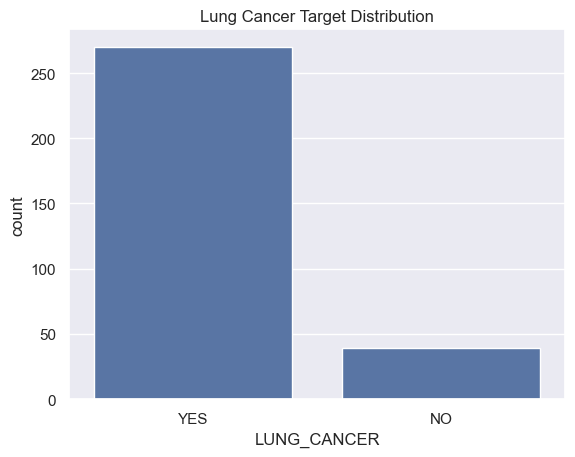

In [13]:
sns.countplot(data=df , x = 'LUNG_CANCER')
plt.title('Lung Cancer Target Distribution')
plt.show()

The target variable is highly imbalanced. Most records belong to the YES class, so accuracy alone is not enough for evaluation.

In [14]:
df_clean = df.drop_duplicates()
df_clean.shape

(276, 16)

In [15]:
df = df_clean.copy()

In [16]:
df['LUNG_CANCER']= df['LUNG_CANCER'].map({'YES':1 , 'NO':0})

In [17]:
df["LUNG_CANCER"].value_counts()

LUNG_CANCER
1    238
0     38
Name: count, dtype: int64

In [18]:
binary_cols = [
    "SMOKING",
    "YELLOW_FINGERS",
    "ANXIETY",
    "PEER_PRESSURE",
    "CHRONIC_DISEASE",
    "FATIGUE",
    "ALLERGY",
    "WHEEZING",
    "ALCOHOL_CONSUMING",
    "COUGHING",
    "SHORTNESS_OF_BREATH",
    "SWALLOWING_DIFFICULTY",
    "CHEST_PAIN"
]

for col in binary_cols:
    df[col] = df[col].map({1: 0, 2: 1})

In [19]:
df[binary_cols].head()

,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
0,0,1,1,0,0,1,0,1,1,1,1,1,1
1,1,0,0,0,1,1,1,0,0,0,1,1,1
2,0,0,0,1,0,1,0,1,0,1,1,0,1
3,1,1,1,0,0,0,0,0,1,0,0,1,1
4,0,1,0,0,0,0,0,1,0,1,1,0,0


In [20]:
df['GENDER']= df['GENDER'].map({'M': 1, 'F': 0})

In [21]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


EDA

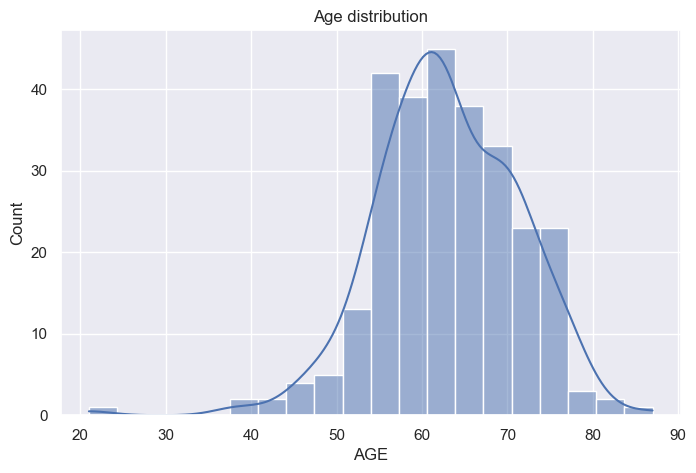

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df,x='AGE', kde=True)
plt.title('Age distribution')
plt.show()

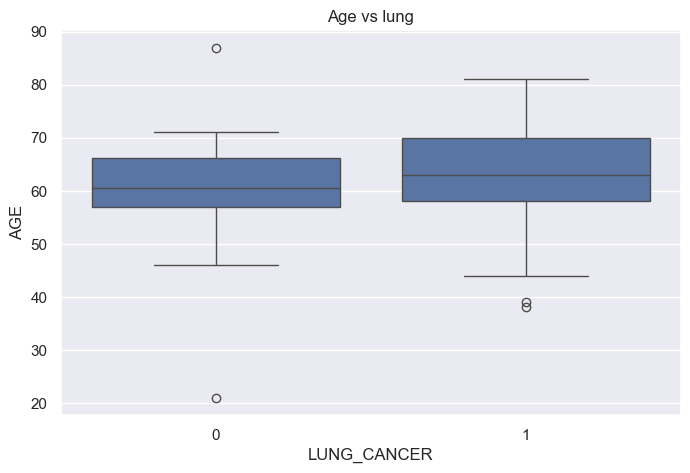

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(df,x='LUNG_CANCER', y='AGE')
plt.title('Age vs lung')
plt.show()

In [24]:
gender_cancer = pd.crosstab(df["GENDER"], df["LUNG_CANCER"], normalize="index") * 100
gender_cancer

LUNG_CANCER,0,1
GENDER,,
0,15.671642,84.328358
1,11.971831,88.028169


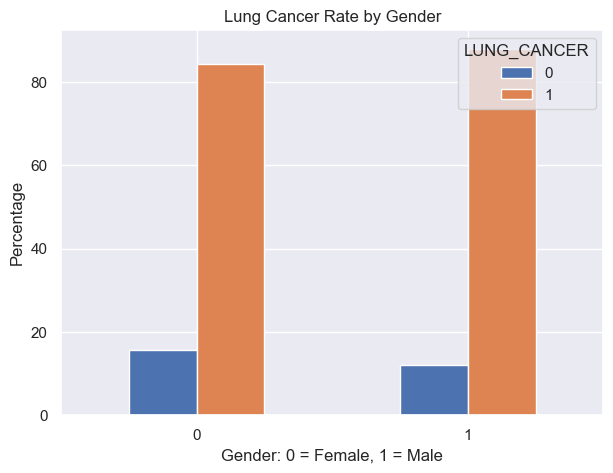

In [25]:
gender_cancer.plot(kind="bar", figsize=(7, 5))
plt.title("Lung Cancer Rate by Gender")
plt.xlabel("Gender: 0 = Female, 1 = Male")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

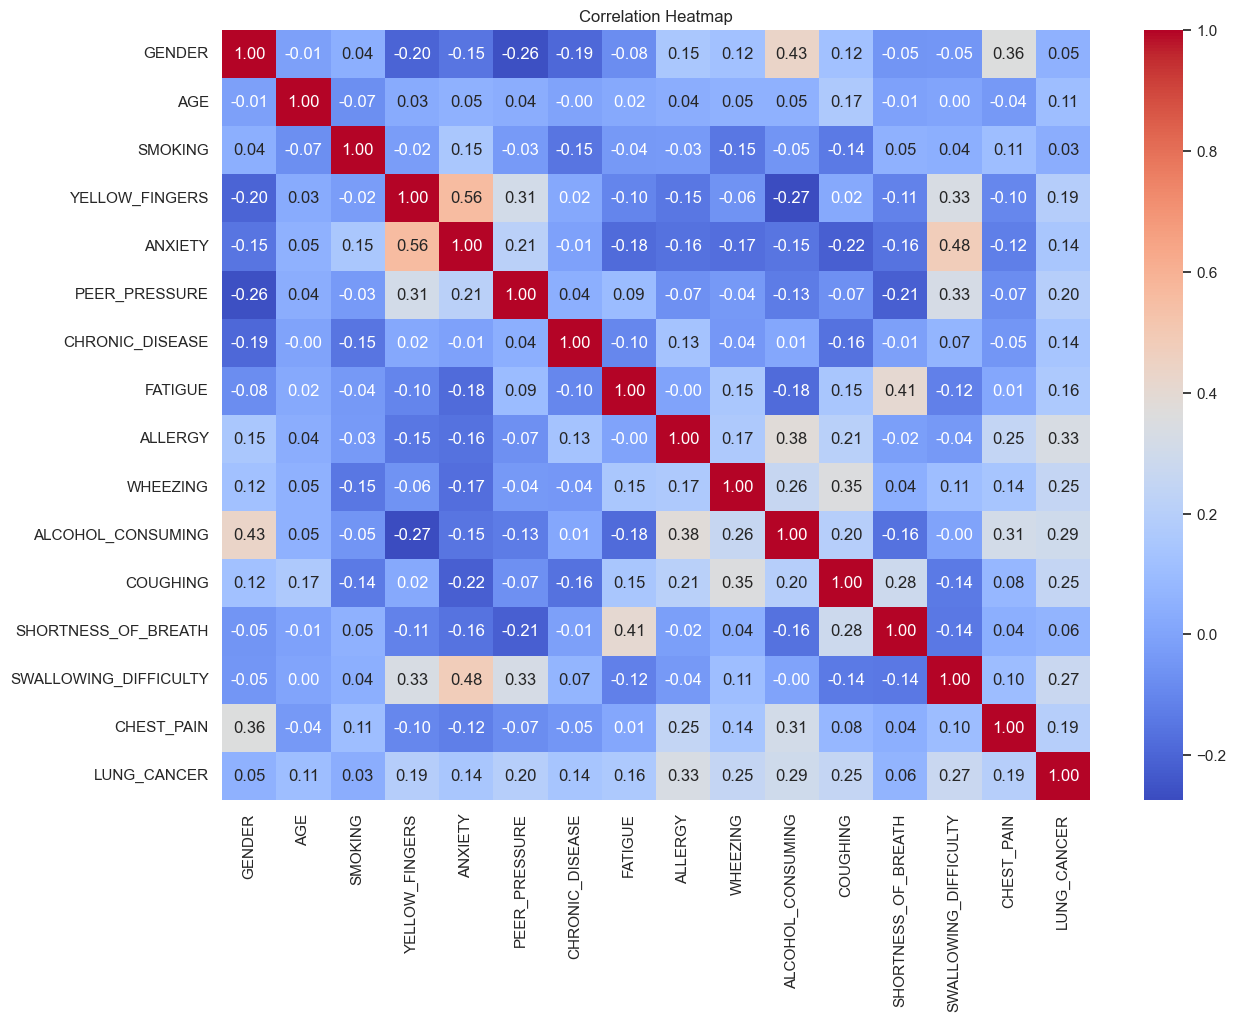

In [26]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
target_corr = df.corr(numeric_only=True)["LUNG_CANCER"].sort_values(ascending=False)

target_corr

LUNG_CANCER              1.000000
ALLERGY                  0.333552
ALCOHOL_CONSUMING        0.294422
SWALLOWING_DIFFICULTY    0.268940
COUGHING                 0.253027
WHEEZING                 0.249054
PEER_PRESSURE            0.195086
CHEST_PAIN               0.194856
YELLOW_FINGERS           0.189192
FATIGUE                  0.160078
ANXIETY                  0.144322
CHRONIC_DISEASE          0.143692
AGE                      0.106305
SHORTNESS_OF_BREATH      0.064407
GENDER                   0.053666
SMOKING                  0.034878
Name: LUNG_CANCER, dtype: float64

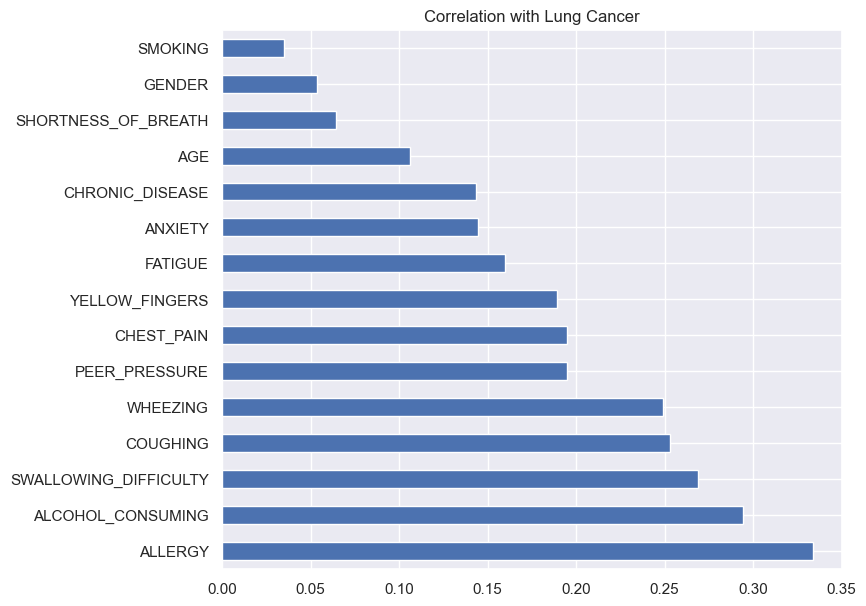

In [28]:
target_corr.drop("LUNG_CANCER").plot(kind="barh", figsize=(8, 7))
plt.title("Correlation with Lung Cancer")
plt.show()

In [29]:
symptom_cols = [
    "YELLOW_FINGERS",
    "ANXIETY",
    "CHRONIC_DISEASE",
    "FATIGUE",
    "ALLERGY",
    "WHEEZING",
    "COUGHING",
    "SHORTNESS_OF_BREATH",
    "SWALLOWING_DIFFICULTY",
    "CHEST_PAIN"
]

df["SYMPTOM_SCORE"] = df[symptom_cols].sum(axis=1)

In [30]:
risk_cols = [
    "SMOKING",
    "ALCOHOL_CONSUMING",
    "PEER_PRESSURE"
]

df["RISK_SCORE"] = df[risk_cols].sum(axis=1)

In [31]:
respiratory_cols = [
    "WHEEZING",
    "COUGHING",
    "SHORTNESS_OF_BREATH",
    "CHEST_PAIN"
]

df["RESPIRATORY_SCORE"] = df[respiratory_cols].sum(axis=1)

In [32]:
df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[0, 40, 55, 70, 100],
    labels=["young", "middle_age", "senior", "elderly"]
)

In [33]:
df[["AGE", "AGE_GROUP", "SYMPTOM_SCORE", "RISK_SCORE", "RESPIRATORY_SCORE"]].head()

,AGE,AGE_GROUP,SYMPTOM_SCORE,RISK_SCORE,RESPIRATORY_SCORE
0,69,senior,8,1,4
1,74,elderly,6,1,2
2,59,senior,5,1,4
3,63,senior,4,2,1
4,63,senior,4,0,3


In [34]:
X = df.drop(columns=["LUNG_CANCER"])
y = df["LUNG_CANCER"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)